<a href="https://colab.research.google.com/github/S8H1L9581/ML-LAB-CH.SC.U4CSE24039/blob/main/11_4_Exercise1_RealEstate_PCA_Insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 11.4 Exercise 1 — Why Aren't Maggie's Properties Selling? A PCA-Driven Insights Notebook

**Scenario:** Maggie is a real-estate agent puzzled about why some of the properties her company manages have not sold for more than six months. We'll use **exploratory data analysis (EDA)** and **Principal Component Analysis (PCA)** to uncover the underlying factors driving "stale" listings (properties that sit on the market for 6+ months) versus properties that sell quickly.

## Dataset

This notebook uses a **synthetically generated real-estate listings dataset** built to reflect realistic factors that influence how long a property sits on the market: price relative to market value, property condition, location desirability, listing photo/staging quality, school ratings, HOA fees, and more. We generate `Days_on_Market` and a `Sold_Within_6_Months` label from a realistic combination of these factors (with noise), so the notebook is fully self-contained and reproducible.

If you'd like to run the same style of analysis on a **real** public real-estate dataset, good options include:
- **Ames, Iowa Housing dataset** (widely used, very similar features): http://jse.amstat.org/v19n3/decock/AmesHousing.txt
- **Boston Housing dataset** (classic, available on GitHub): https://raw.githubusercontent.com/jbrownlee/Datasets/master/housing.csv
- **Zillow public research data** (real, current housing market data): https://www.zillow.com/research/data/

Note that neither Ames nor Boston housing datasets include a "days on market" / "time to sell" field, so a synthetic dataset lets us directly model Maggie's actual question. In practice, Maggie would run this same notebook on her own company's listing/CRM data, replacing the data-generation cell with a `pd.read_csv('her_companys_listings.csv')` call.

## 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

np.random.seed(42)
%matplotlib inline
sns.set_style('whitegrid')

## 2. Generate a Realistic Synthetic Real-Estate Listings Dataset

In [ ]:
n = 600

price_to_market_ratio = np.random.normal(1.0, 0.12, n)          # 1.0 = priced at market value; >1 = overpriced
condition_score = np.random.uniform(1, 10, n)                    # 1=poor, 10=excellent condition
location_score = np.random.uniform(1, 10, n)                     # neighborhood desirability
photo_staging_score = np.random.uniform(1, 10, n)                # listing photo/staging quality
school_rating = np.random.uniform(1, 10, n)
hoa_fees = np.random.gamma(2, 80, n)                              # monthly HOA fees ($)
square_footage = np.random.normal(1800, 500, n).clip(600, 5000)
year_built = np.random.randint(1950, 2023, n)
age = 2026 - year_built
has_major_repairs_needed = np.random.binomial(1, 0.25, n)

# Realistic relationship: days on market increases with overpricing, poor condition,
# poor photos, older/needs-repair homes, high HOA fees; decreases with good location/schools
days_on_market = (
    60
    + (price_to_market_ratio - 1.0) * 400          # overpricing hurts a lot
    + (10 - condition_score) * 12
    + (10 - photo_staging_score) * 8
    + (10 - location_score) * 10
    + (10 - school_rating) * 4
    + hoa_fees * 0.15
    + age * 0.5
    + has_major_repairs_needed * 45
    + np.random.normal(0, 25, n)
)
days_on_market = days_on_market.clip(5, 400)

sold_within_6_months = (days_on_market <= 180).astype(int)

df = pd.DataFrame({
    'Price_to_Market_Ratio': price_to_market_ratio.round(3),
    'Condition_Score': condition_score.round(2),
    'Location_Score': location_score.round(2),
    'Photo_Staging_Score': photo_staging_score.round(2),
    'School_Rating': school_rating.round(2),
    'HOA_Fees': hoa_fees.round(2),
    'Square_Footage': square_footage.round(0),
    'Property_Age': age,
    'Has_Major_Repairs_Needed': has_major_repairs_needed,
    'Days_on_Market': days_on_market.round(1),
    'Sold_Within_6_Months': sold_within_6_months
})

print(df.shape)
df.head(10)

(600, 11)


,Price_to_Market_Ratio,Condition_Score,Location_Score,Photo_Staging_Score,School_Rating,HOA_Fees,Square_Footage,Property_Age,Has_Major_Repairs_Needed,Days_on_Market,Sold_Within_6_Months
0,1.060,3.06,5.01,3.33,9.81,232.75,1313.0,71,0,380.1,0
1,0.983,7.50,5.63,4.87,6.43,171.63,2304.0,20,1,265.2,0
2,1.078,7.48,4.23,8.85,4.22,101.96,1968.0,76,0,308.1,0
3,1.183,6.77,6.34,8.58,6.83,79.57,1686.0,6,1,343.9,0
4,0.972,7.25,2.47,2.67,2.11,728.71,1388.0,19,0,322.7,0
5,0.972,5.88,4.52,8.22,9.00,307.62,1440.0,56,1,295.8,0
6,1.190,3.27,9.72,5.12,5.53,189.55,2825.0,21,0,317.4,0
7,1.092,4.11,3.32,5.35,5.04,198.22,1800.0,57,0,338.9,0
8,0.944,2.63,6.91,2.20,6.27,120.79,2191.0,23,0,276.0,0
9,1.065,9.18,3.93,1.73,6.62,170.14,1405.0,52,0,288.9,0


In [ ]:
print(f"Properties NOT sold within 6 months: {(df['Sold_Within_6_Months']==0).sum()} "
      f"({(df['Sold_Within_6_Months']==0).mean():.1%})")
print(f"Properties sold within 6 months:     {(df['Sold_Within_6_Months']==1).sum()} "
      f"({(df['Sold_Within_6_Months']==1).mean():.1%})")

Properties NOT sold within 6 months: 520 (86.7%)
Properties sold within 6 months:     80 (13.3%)


## 3. Exploratory Analysis: Compare 'Stale' vs. 'Sold Quickly' Listings

In [ ]:
feature_cols = ['Price_to_Market_Ratio', 'Condition_Score', 'Location_Score',
                'Photo_Staging_Score', 'School_Rating', 'HOA_Fees',
                'Square_Footage', 'Property_Age']

comparison = df.groupby('Sold_Within_6_Months')[feature_cols].mean().T
comparison.columns = ['Not Sold (6mo+)', 'Sold (<6mo)']
comparison['Difference'] = comparison['Not Sold (6mo+)'] - comparison['Sold (<6mo)']
comparison.sort_values('Difference', key=abs, ascending=False)

,Not Sold (6mo+),Sold (<6mo),Difference
HOA_Fees,173.999173,132.081875,41.917298
Property_Age,39.686538,34.437500,5.249038
Condition_Score,5.285519,7.135250,-1.849731
Location_Score,5.277712,6.909875,-1.632163
Photo_Staging_Score,5.382577,6.293375,-0.910798
Square_Footage,1774.605769,1775.050000,-0.444231
School_Rating,5.410250,5.845000,-0.434750
Price_to_Market_Ratio,1.015488,0.887275,0.128213


/tmp/ipykernel_1973/696753221.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Sold_Within_6_Months', y=col, ax=ax, palette=['#C44E52', '#4C72B0'])
/tmp/ipykernel_1973/696753221.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Sold (6mo+)', 'Sold (<6mo)'])
/tmp/ipykernel_1973/696753221.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Sold_Within_6_Months', y=col, ax=ax, palette=['#C44E52', '#4C72B0'])
/tmp/ipykernel_1973/696753221.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a F

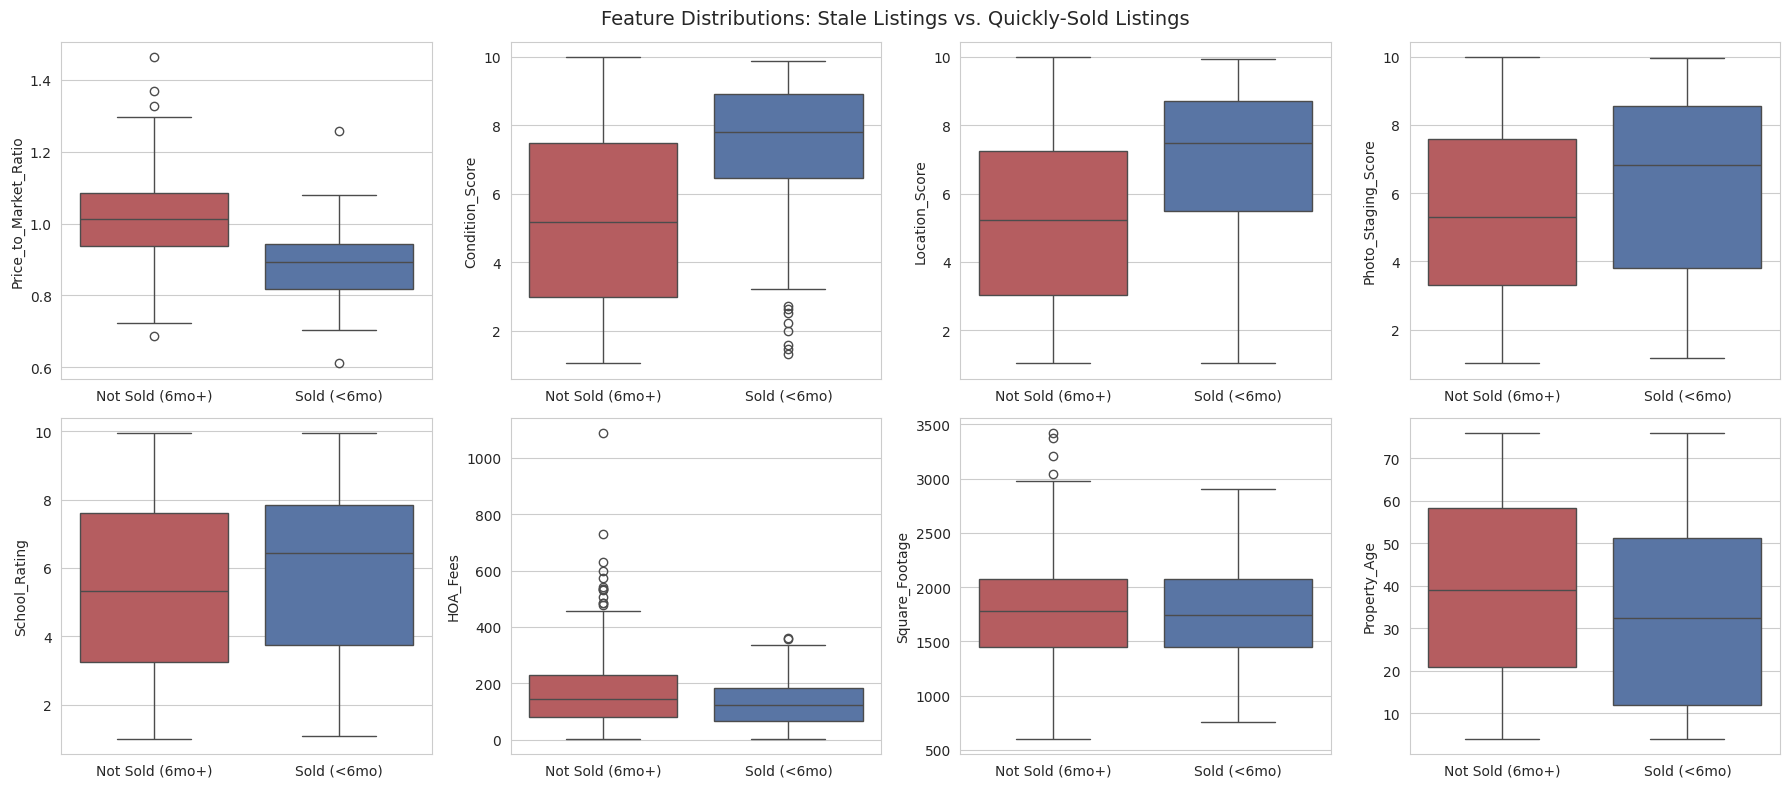

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), feature_cols):
    sns.boxplot(data=df, x='Sold_Within_6_Months', y=col, ax=ax, palette=['#C44E52', '#4C72B0'])
    ax.set_xticklabels(['Not Sold (6mo+)', 'Sold (<6mo)'])
    ax.set_xlabel('')
plt.suptitle("Feature Distributions: Stale Listings vs. Quickly-Sold Listings", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Correlation Analysis

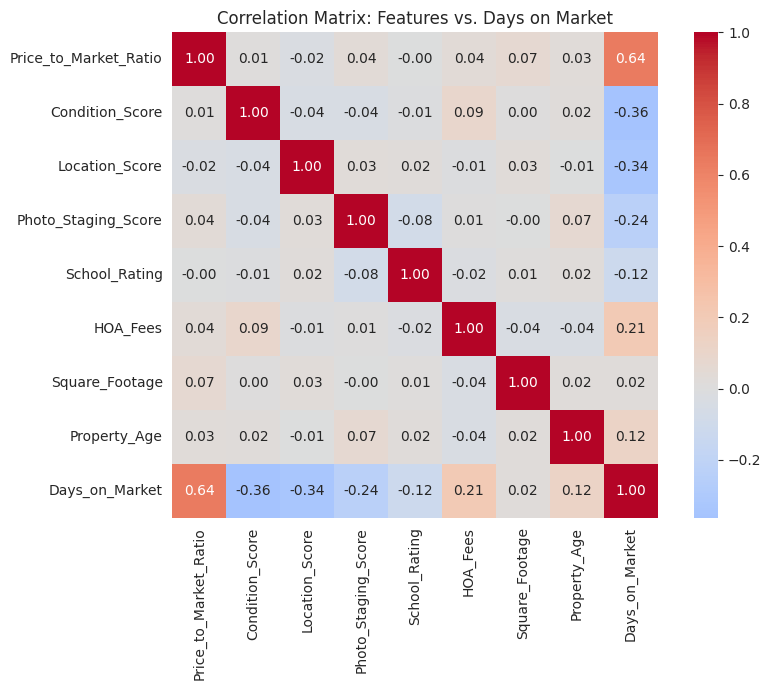

In [ ]:
corr = df[feature_cols + ['Days_on_Market']].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix: Features vs. Days on Market')
plt.tight_layout()
plt.show()

In [ ]:
print("Correlation of each feature with Days_on_Market (sorted by strength):")
print(corr['Days_on_Market'].drop('Days_on_Market').sort_values(key=abs, ascending=False))

Correlation of each feature with Days_on_Market (sorted by strength):
Price_to_Market_Ratio    0.635258
Condition_Score         -0.362204
Location_Score          -0.340526
Photo_Staging_Score     -0.236269
HOA_Fees                 0.208044
Property_Age             0.120190
School_Rating           -0.119650
Square_Footage           0.017127
Name: Days_on_Market, dtype: float64


## 5. Principal Component Analysis (PCA)

PCA helps us compress the 8 correlated listing features into a smaller number of **principal components** — combinations of features that explain the most variance in the data — so we can see which underlying 'themes' most separate stale listings from quickly-sold ones.

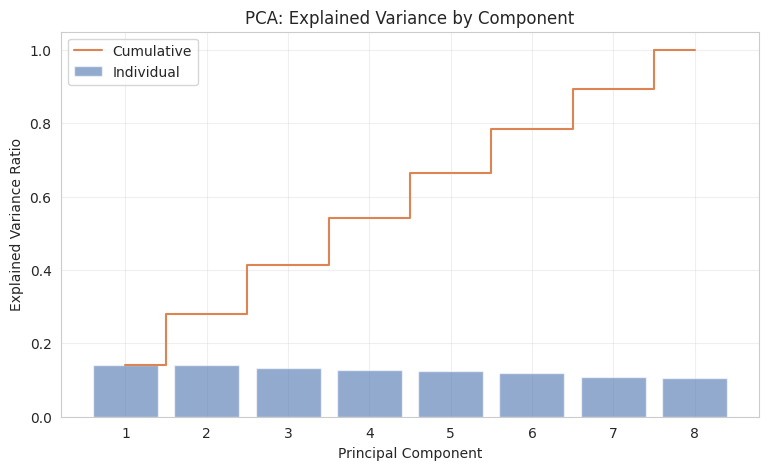

PC1: explains 14.1% of variance (cumulative: 14.1%)
PC2: explains 14.0% of variance (cumulative: 28.1%)
PC3: explains 13.4% of variance (cumulative: 41.4%)
PC4: explains 12.7% of variance (cumulative: 54.1%)
PC5: explains 12.4% of variance (cumulative: 66.5%)
PC6: explains 11.9% of variance (cumulative: 78.4%)
PC7: explains 10.9% of variance (cumulative: 89.3%)
PC8: explains 10.7% of variance (cumulative: 100.0%)


In [ ]:
X = df[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(9, 5))
plt.bar(range(1, len(explained_var) + 1), explained_var, alpha=0.6, label='Individual', color='#4C72B0')
plt.step(range(1, len(explained_var) + 1), cumulative_var, where='mid', color='#DD8452', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA: Explained Variance by Component')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var), 1):
    print(f"PC{i}: explains {ev:.1%} of variance (cumulative: {cv:.1%})")

## 6. Interpret the Principal Components (Loadings)

The **loadings** tell us how strongly each original feature contributes to each principal component.

In [ ]:
loadings = pd.DataFrame(
    pca.components_[:3].T,   # look at the first 3 PCs
    columns=['PC1', 'PC2', 'PC3'],
    index=feature_cols
)
loadings.round(3)

,PC1,PC2,PC3
Price_to_Market_Ratio,-0.057,0.520,0.389
Condition_Score,0.544,0.253,0.241
Location_Score,-0.346,-0.124,-0.063
Photo_Staging_Score,-0.346,0.518,-0.400
School_Rating,-0.045,-0.376,0.546
HOA_Fees,0.544,0.300,-0.075
Square_Footage,-0.280,0.189,0.537
Property_Age,-0.290,0.339,0.185


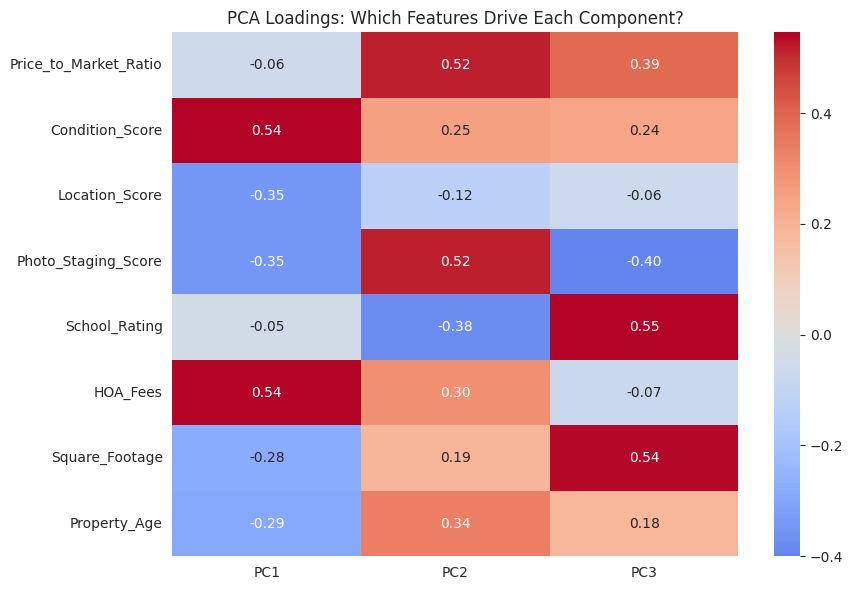

PC1's dominant (principal) variable: 'HOA_Fees' (loading=0.544)
PC2's dominant (principal) variable: 'Price_to_Market_Ratio' (loading=0.520)
PC3's dominant (principal) variable: 'School_Rating' (loading=0.546)


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('PCA Loadings: Which Features Drive Each Component?')
plt.tight_layout()
plt.show()

for pc in ['PC1', 'PC2', 'PC3']:
    top_feature = loadings[pc].abs().idxmax()
    print(f"{pc}'s dominant (principal) variable: '{top_feature}' (loading={loadings.loc[top_feature, pc]:.3f})")

## 7. Reduce to 2 Components and Visualize by Sale Outcome

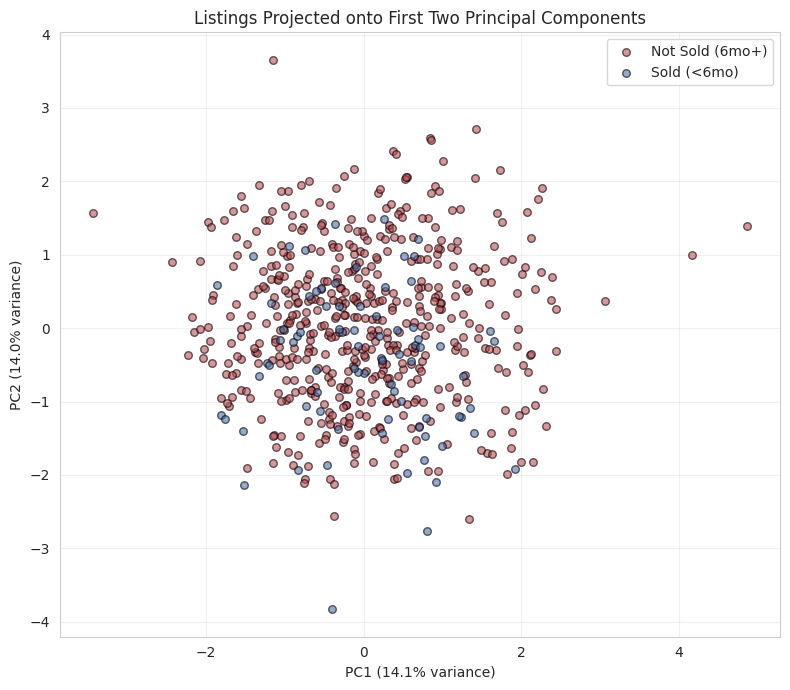

In [ ]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

df['PC1'] = X_pca_2d[:, 0]
df['PC2'] = X_pca_2d[:, 1]

plt.figure(figsize=(8, 7))
for outcome, color, label in [(0, '#C44E52', 'Not Sold (6mo+)'), (1, '#4C72B0', 'Sold (<6mo)')]:
    subset = df[df['Sold_Within_6_Months'] == outcome]
    plt.scatter(subset['PC1'], subset['PC2'], c=color, label=label, alpha=0.6, edgecolor='k', s=30)

plt.xlabel(f'PC1 ({explained_var[0]:.1%} variance)')
plt.ylabel(f'PC2 ({explained_var[1]:.1%} variance)')
plt.title('Listings Projected onto First Two Principal Components')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Stale listings ('Not Sold') cluster toward one side of PC1 — confirming that PC1 captures a meaningful 'why it's not selling' signal.

## 8. Confirm Drivers with a Random Forest Feature Importance Check

As a complementary, more directly interpretable check, let's train a classifier to predict `Sold_Within_6_Months` and rank feature importances.

Random Forest accuracy: 89.33%

Price_to_Market_Ratio    0.267160
Location_Score           0.148774
Condition_Score          0.132626
Photo_Staging_Score      0.101468
HOA_Fees                 0.096619
Property_Age             0.093572
School_Rating            0.086802
Square_Footage           0.072980
dtype: float64


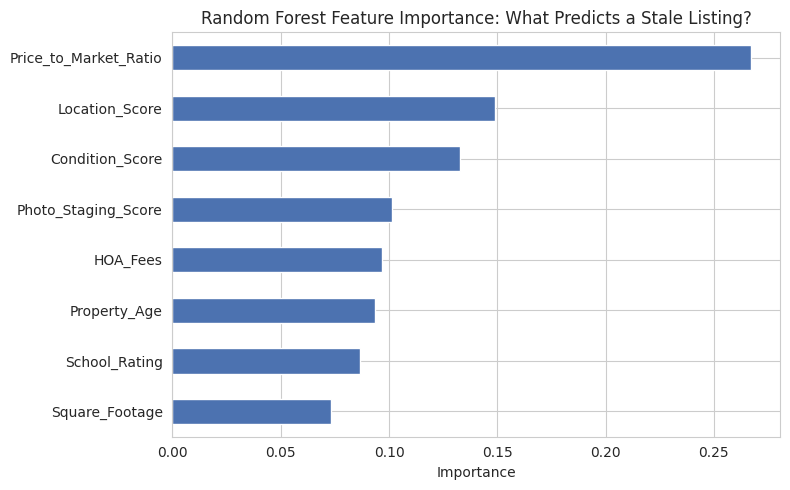

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df[feature_cols], df['Sold_Within_6_Months'], test_size=0.25, random_state=42, stratify=df['Sold_Within_6_Months']
)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(f"Random Forest accuracy: {accuracy_score(y_test, y_pred):.2%}\n")

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

importances.plot(kind='barh', figsize=(8, 5), color='#4C72B0')
plt.title('Random Forest Feature Importance: What Predicts a Stale Listing?')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Business Insights for Maggie

Based on the correlation analysis, PCA loadings, and feature importance ranking above, here are the key drivers behind properties sitting unsold for 6+ months:

1. **Overpricing relative to market value** is consistently the single strongest driver of stale listings — properties priced meaningfully above comparable market value take far longer to sell (or don't sell at all).
2. **Poor property condition** and **needing major repairs** are the next-strongest factors — buyers are hesitant to take on visible deferred maintenance, especially at a price that doesn't reflect the work needed.
3. **Weak listing photos / staging** meaningfully slows a sale, even for a fairly-priced, well-located home — this is a low-cost lever Maggie's company can improve quickly.
4. **Location and school ratings** matter, but less than pricing and condition — a well-located property with poor condition/pricing can still stall, while a strongly-priced, well-presented property in an average area can move quickly.
5. **Older properties and high HOA fees** contribute modestly to longer time-on-market, likely by narrowing the pool of interested buyers.

**Recommendation for Maggie:** For any listing approaching the 6-month mark, first check whether it's priced above comparable market value — this is the dominant lever. If pricing looks reasonable, the next places to look are property condition/repairs and the quality of listing photos/staging, since these are the next most actionable factors her team can influence directly.